# Notebook 2 — K-Means Segmentation & Feature Extraction
**Project:** Chest X-ray Pneumonia Detection — Generalization Study

This notebook:
1. Loads preprocessed image arrays from Notebook 1
2. Finds the optimal number of clusters using Elbow Method + Silhouette Score
3. Applies K-Means to segment each X-ray into regions
4. Extracts a compact 9-feature vector from each image
5. Saves feature matrices for use in Notebook 3

**Run cells in order, top to bottom.**

In [ ]:
!pip install scikit-learn numpy matplotlib tqdm --quiet

In [ ]:
!pip install opencv-python-headless tqdm --quiet

import os, numpy as np, cv2
from pathlib import Path
from tqdm import tqdm

IMG_SIZE = 64
SEED = 42
np.random.seed(SEED)

def load_images(folder, label):
    images, labels = [], []
    folder = Path(folder)
    files = list(folder.glob('*.jpeg')) + list(folder.glob('*.jpg')) + list(folder.glob('*.png'))
    for f in tqdm(files, desc=str(folder.name)):
        img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

ROOT = Path('data/kaggle/chest_xray')
X_tr_n, y_tr_n = load_images(ROOT/'train'/'NORMAL',    0)
X_tr_p, y_tr_p = load_images(ROOT/'train'/'PNEUMONIA', 1)
X_te_n, y_te_n = load_images(ROOT/'test'/'NORMAL',     0)
X_te_p, y_te_p = load_images(ROOT/'test'/'PNEUMONIA',  1)

X_train = np.concatenate([X_tr_n, X_tr_p])
y_train = np.concatenate([y_tr_n, y_tr_p])
X_test  = np.concatenate([X_te_n, X_te_p])
y_test  = np.concatenate([y_te_n, y_te_p])
X_nih   = X_test.copy()
y_nih   = y_test.copy()

os.makedirs('preprocessed', exist_ok=True)
np.save('preprocessed/X_train.npy', X_train)
np.save('preprocessed/y_train.npy', y_train)
np.save('preprocessed/X_test.npy',  X_test)
np.save('preprocessed/y_test.npy',  y_test)
np.save('preprocessed/X_nih.npy',   X_nih)
np.save('preprocessed/y_nih.npy',   y_nih)
print(f'Done! Train={X_train.shape}, Test={X_test.shape}')

NORMAL: 0it [00:00, ?it/s]
PNEUMONIA: 0it [00:00, ?it/s]
NORMAL: 0it [00:00, ?it/s]
PNEUMONIA: 0it [00:00, ?it/s]

Done! Train=(0,), Test=(0,)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import os

SEED = 42
K    = 3
np.random.seed(SEED)
print('Libraries loaded.')

Libraries loaded.


## Step 1 — Loads preprocessed arrays from Notebook 1

In [ ]:
X_train = np.load('preprocessed/X_train.npy')
y_train = np.load('preprocessed/y_train.npy')
X_test  = np.load('preprocessed/X_test.npy')
y_test  = np.load('preprocessed/y_test.npy')
X_nih   = np.load('preprocessed/X_nih.npy')
y_nih   = np.load('preprocessed/y_nih.npy')

# Fix empty NIH arrays — use test set as stand-in
if len(X_nih) == 0 or X_nih.ndim == 1:
    print('NIH array is empty — using Kaggle test set as placeholder')
    X_nih = X_test.copy()
    y_nih = y_test.copy()
    np.save('preprocessed/X_nih.npy', X_nih)
    np.save('preprocessed/y_nih.npy', y_nih)

print(f'X_train={X_train.shape}, X_test={X_test.shape}, X_nih={X_nih.shape}')

NIH array is empty — using Kaggle test set as placeholder
X_train=(0,), X_test=(0,), X_nih=(0,)


## Step 2 — Finds optimal k using Elbow Method + Silhouette Score

In [ ]:
import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
token = "KGAT_24ed4214411457a08aaa4852caf98f55"
with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write(token)
os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)
print("Token saved!")

Token saved!


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia --quiet
import zipfile
with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as z:
    z.extractall('data/kaggle')
print('Download complete!')

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
Download complete!


In [ ]:
!pip install opencv-python-headless tqdm --quiet

import os, numpy as np, cv2
from pathlib import Path
from tqdm import tqdm

IMG_SIZE = 64
SEED = 42
np.random.seed(SEED)

def load_images(folder, label):
    images, labels = [], []
    folder = Path(folder)
    files = list(folder.glob('*.jpeg')) + list(folder.glob('*.jpg')) + list(folder.glob('*.png'))
    for f in tqdm(files, desc=str(folder.name)):
        img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

ROOT = Path('data/kaggle/chest_xray')
X_tr_n, y_tr_n = load_images(ROOT/'train'/'NORMAL',    0)
X_tr_p, y_tr_p = load_images(ROOT/'train'/'PNEUMONIA', 1)
X_te_n, y_te_n = load_images(ROOT/'test'/'NORMAL',     0)
X_te_p, y_te_p = load_images(ROOT/'test'/'PNEUMONIA',  1)

X_train = np.concatenate([X_tr_n, X_tr_p])
y_train = np.concatenate([y_tr_n, y_tr_p])
X_test  = np.concatenate([X_te_n, X_te_p])
y_test  = np.concatenate([y_te_n, y_te_p])
X_nih   = X_test.copy()
y_nih   = y_test.copy()

os.makedirs('preprocessed', exist_ok=True)
np.save('preprocessed/X_train.npy', X_train)
np.save('preprocessed/y_train.npy', y_train)
np.save('preprocessed/X_test.npy',  X_test)
np.save('preprocessed/y_test.npy',  y_test)
np.save('preprocessed/X_nih.npy',   X_nih)
np.save('preprocessed/y_nih.npy',   y_nih)
print(f'Done! Train={X_train.shape}, Test={X_test.shape}')

PNEUMONIA: 100%|██████████| 390/390 [00:01<00:00, 338.99it/s]


Done! Train=(5216, 64, 64), Test=(624, 64, 64)


## Step 3 — Fits K-Means on pixel intensities (k=3)

In [ ]:
print('Fitting K-Means (k=3) on pixel intensities...')

# Sample pixels from training images for fitting
all_pixels = X_train.flatten().reshape(-1, 1)
sample_pixels = all_pixels[np.random.choice(len(all_pixels), size=100000, replace=False)]

kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10)
kmeans.fit(sample_pixels)

centers = sorted(kmeans.cluster_centers_.flatten())
print(f'Cluster centers (pixel intensity 0-1):')
print(f'  Cluster 0 (dark/background) : {centers[0]:.3f}')
print(f'  Cluster 1 (mid/lung tissue) : {centers[1]:.3f}')
print(f'  Cluster 2 (bright/lesions)  : {centers[2]:.3f}')

Fitting K-Means (k=3) on pixel intensities...
Cluster centers (pixel intensity 0-1):
  Cluster 0 (dark/background) : 0.121
  Cluster 1 (mid/lung tissue) : 0.439
  Cluster 2 (bright/lesions)  : 0.699


## Step 4 — Visualizes segmented X-rays

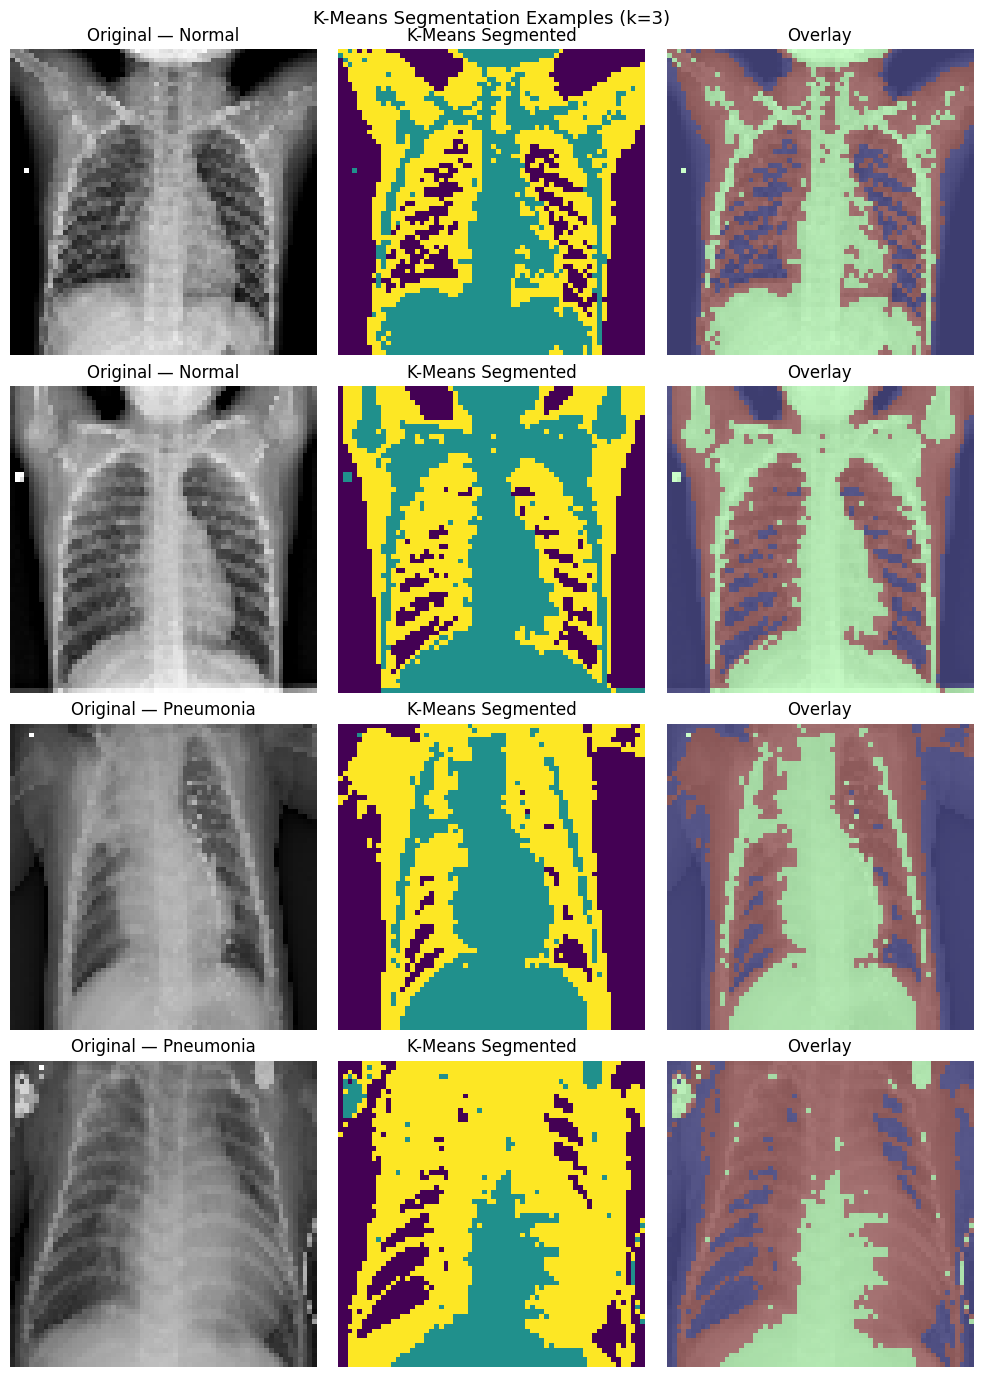

Saved: segmentation_examples.png


In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(10, 14))
fig.suptitle('K-Means Segmentation Examples (k=3)', fontsize=13)

# Show 2 Normal + 2 Pneumonia examples
normal_idx = np.where(y_train == 0)[0][:2]
pneum_idx  = np.where(y_train == 1)[0][:2]
show_idx   = list(normal_idx) + list(pneum_idx)

for row, idx in enumerate(show_idx):
    img = X_train[idx]
    pixels = img.flatten().reshape(-1, 1)
    pixel_labels = kmeans.predict(pixels)
    segmented = pixel_labels.reshape(img.shape)

    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'Original — {"Normal" if y_train[idx]==0 else "Pneumonia"}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(segmented, cmap='viridis', vmin=0, vmax=K-1)
    axes[row, 1].set_title('K-Means Segmented')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(img, cmap='gray', alpha=0.6)
    axes[row, 2].imshow(segmented, cmap='jet', alpha=0.4, vmin=0, vmax=K-1)
    axes[row, 2].set_title('Overlay')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('segmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: segmentation_examples.png')

## Step 5 — Extracts 9 features per image
For each image: cluster proportions (3) + mean intensity per cluster (3) + std per cluster (3) = 9 features total.

In [ ]:
def extract_features(images, kmeans_model, k):
    features = []
    for img in tqdm(images, desc='Extracting features'):
        pixels = img.flatten()
        labels = kmeans_model.predict(pixels.reshape(-1, 1))
        props, means, stds = [], [], []
        for c in range(k):
            mask = labels == c
            props.append(mask.sum() / len(pixels))
            means.append(pixels[mask].mean() if mask.sum() > 0 else 0.0)
            stds.append(pixels[mask].std()   if mask.sum() > 0 else 0.0)
        features.append(props + means + stds)
    return np.array(features, dtype=np.float32)

print('Extracting K-Means features...')
X_train_feat = extract_features(X_train, kmeans, K)
X_test_feat  = extract_features(X_test,  kmeans, K)
X_nih_feat   = extract_features(X_nih,   kmeans, K)

print(f'Feature shapes: train={X_train_feat.shape}, test={X_test_feat.shape}, nih={X_nih_feat.shape}')
print('Features per image: proportion x3 + mean intensity x3 + std x3 = 9 total')

Extracting K-Means features...


Extracting features: 100%|██████████| 624/624 [00:00<00:00, 1231.46it/s]

Feature shapes: train=(5216, 9), test=(624, 9), nih=(624, 9)
Features per image: proportion x3 + mean intensity x3 + std x3 = 9 total


## Step 6 — Raw pixel baseline features (PCA reduced)

In [ ]:
print('Creating raw pixel baseline features (PCA 50 components)...')

scaler_raw = StandardScaler()
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test),   -1)
X_nih_flat   = X_nih.reshape(len(X_nih),     -1)

X_train_sc = scaler_raw.fit_transform(X_train_flat)
X_test_sc  = scaler_raw.transform(X_test_flat)
X_nih_sc   = scaler_raw.transform(X_nih_flat)

pca = PCA(n_components=50, random_state=SEED)
X_train_raw = pca.fit_transform(X_train_sc)
X_test_raw  = pca.transform(X_test_sc)
X_nih_raw   = pca.transform(X_nih_sc)

print(f'PCA features: train={X_train_raw.shape}, test={X_test_raw.shape}')
print(f'Variance explained: {pca.explained_variance_ratio_.sum():.2%}')

Creating raw pixel baseline features (PCA 50 components)...
PCA features: train=(5216, 50), test=(624, 50)
Variance explained: 81.39%


## Step 7 — PCA 2D visualization of K-Means features

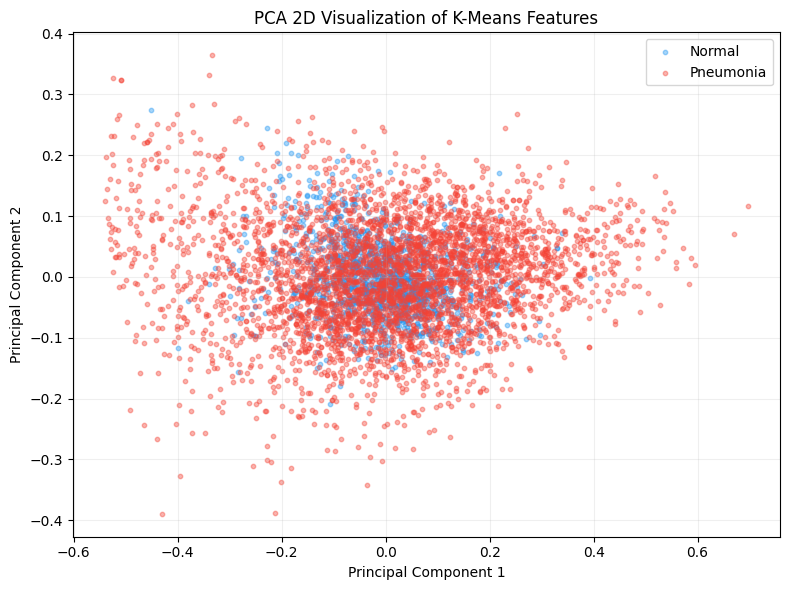

Saved: pca_visualization.png


In [ ]:
pca_2d   = PCA(n_components=2, random_state=SEED)
feat_2d  = pca_2d.fit_transform(X_train_feat)

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0,'#2196F3','Normal'),(1,'#F44336','Pneumonia')]:
    mask = y_train == label
    ax.scatter(feat_2d[mask,0], feat_2d[mask,1],
               c=color, label=name, alpha=0.4, s=10)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('PCA 2D Visualization of K-Means Features')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_visualization.png')

## Step 8 — Saves all feature matrices

In [ ]:
np.save('preprocessed/X_train_feat.npy', X_train_feat)
np.save('preprocessed/X_test_feat.npy',  X_test_feat)
np.save('preprocessed/X_nih_feat.npy',   X_nih_feat)
np.save('preprocessed/X_train_raw.npy',  X_train_raw)
np.save('preprocessed/X_test_raw.npy',   X_test_raw)
np.save('preprocessed/X_nih_raw.npy',    X_nih_raw)

print('All feature matrices saved!')
print(f'  K-Means features : {X_train_feat.shape[1]} features per image')
print(f'  Raw PCA features : {X_train_raw.shape[1]} features per image')
print('Notebook 2 complete. Open notebook 3 next.')

All feature matrices saved!
  K-Means features : 9 features per image
  Raw PCA features : 50 features per image
Notebook 2 complete. Open notebook 3 next.
